# 01 - Análisis exploratorio (EDA) de la serie horaria de ozono troposférico (O3)

En este notebook, se realiza el análisis exploratorio inicial de la serie de ozono troposférico (O3) registrada por la estación del Eixample (para el periodo 2020-2025).

Los objetivos principales de la EDA son los siguientes:

1. Realizar la carga del conjunto bruto de datos.
2. Inspeccionar la estructura de este.
3. Convertir el formato diario ancho, (esto es, con columnas `h01`-`h24`), en una serie temporal horaria.
4. Evaluar la calidad de los datos: rango temporal, duplicados, valores ausentes y continuidad.
5. Generar las primeras tablas y figuras que servirán para la memoria.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.stattools import acf

# Se amplía el número de columnas visibles para inspeccionar mejor el dataset.
pd.set_option("display.max_columns", 100)

# Se evita que pandas corte demasiado pronto el contenido de algunas salidas.
pd.set_option("display.max_rows", 100)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    start = Path.cwd() if start is None else start

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("No se ha podido localizar la raíz del proyecto.")


# Se localiza automáticamente la carpeta raíz del repositorio.
PROJECT_ROOT = find_project_root()

# Ruta del conjunto de datos bruto.
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Eixample_O3_2020_2025.csv"

# Carpetas donde se guardarán las tablas y figuras generadas durante la EDA.
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_GENERATED_DIR = PROJECT_ROOT / "reports" / "figures" / "generated"

# Se comprueba que las carpetas de salida existen antes de guardar resultados.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_GENERATED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Archivo bruto: {RAW_DATA_PATH}")

Raíz del proyecto: c:\trabajo_github
Archivo bruto: c:\trabajo_github\data\raw\Eixample_O3_2020_2025.csv


In [3]:
# Se carga el conjunto de datos bruto sin aplicar, todavía, ninguna transformación.
# En esta fase inicial se comprobará su tamaño, estructura y se obtendrá una muestra de sus primeras filas.
raw_df = pd.read_csv(RAW_DATA_PATH)

print(f"Filas: {raw_df.shape[0]:,}")
print(f"Columnas: {raw_df.shape[1]:,}")

display(raw_df.head())
display(raw_df.tail())

Filas: 2,192
Columnas: 40


,codi_eoi,nom_estacio,data,magnitud,contaminant,unitats,tipus_estacio,area_urbana,codi_ine,municipi,codi_comarca,nom_comarca,h01,h02,h03,h04,h05,h06,h07,h08,h09,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,altitud,latitud,longitud,geocoded_column
0,8019043,Barcelona (Eixample),2025-12-31T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,12.0,34.0,28.0,29.0,22.0,26.0,31.0,29.0,26.0,23.0,28.0,30.0,39.0,43.0,35.0,36.0,24.0,23.0,29.0,25.0,32.0,36.0,39.0,42.0,26,41.385315,2.1538,NaN
1,8019043,Barcelona (Eixample),2025-12-30T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,10.0,21.0,28.0,27.0,29.0,37.0,39.0,30.0,33.0,36.0,36.0,34.0,30.0,29.0,35.0,39.0,34.0,34.0,37.0,37.0,27.0,6.0,4.0,14.0,26,41.385315,2.1538,NaN
2,8019043,Barcelona (Eixample),2025-12-29T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,28.0,35.0,36.0,45.0,54.0,53.0,42.0,16.0,15.0,NaN,NaN,NaN,29.0,30.0,46.0,46.0,34.0,26.0,19.0,5.0,3.0,3.0,3.0,3.0,26,41.385315,2.1538,NaN
3,8019043,Barcelona (Eixample),2025-12-28T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,64.0,64.0,53.0,61.0,50.0,54.0,51.0,46.0,40.0,41.0,51.0,65.0,71.0,77.0,73.0,71.0,70.0,68.0,60.0,41.0,27.0,30.0,32.0,33.0,26,41.385315,2.1538,NaN
4,8019043,Barcelona (Eixample),2025-12-27T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,67.0,67.0,74.0,75.0,74.0,63.0,73.0,76.0,77.0,80.0,72.0,58.0,73.0,67.0,70.0,73.0,73.0,75.0,72.0,66.0,68.0,73.0,71.0,69.0,26,41.385315,2.1538,NaN


,codi_eoi,nom_estacio,data,magnitud,contaminant,unitats,tipus_estacio,area_urbana,codi_ine,municipi,codi_comarca,nom_comarca,h01,h02,h03,h04,h05,h06,h07,h08,h09,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,altitud,latitud,longitud,geocoded_column
2187,8019043,Barcelona (Eixample),2020-01-05T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,31.0,15.0,19.0,31.0,29.0,24.0,22.0,19.0,8.0,11.0,8.0,8.0,10.0,4.0,12.0,33.0,29.0,22.0,9.0,1.0,1.0,1.0,2.0,3.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2188,8019043,Barcelona (Eixample),2020-01-04T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,5.0,11.0,14.0,28.0,28.0,19.0,23.0,27.0,25.0,22.0,26.0,8.0,15.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2189,8019043,Barcelona (Eixample),2020-01-03T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,1.0,17.0,35.0,33.0,25.0,28.0,17.0,11.0,9.0,10.0,7.0,11.0,11.0,11.0,10.0,6.0,4.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2190,8019043,Barcelona (Eixample),2020-01-02T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,4.0,5.0,5.0,4.0,1.0,1.0,2.0,1.0,2.0,4.0,9.0,22.0,31.0,33.0,33.0,34.0,37.0,22.0,2.0,2.0,2.0,5.0,9.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2191,8019043,Barcelona (Eixample),2020-01-01T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,22.0,19.0,19.0,6.0,8.0,5.0,4.0,2.0,2.0,8.0,13.0,25.0,27.0,19.0,22.0,25.0,26.0,18.0,16.0,15.0,13.0,11.0,3.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)


In [4]:
# Las columnas h01-h24 contienen las mediciones horarias correspondientes a cada día.
hour_columns = [f"h{hour:02d}" for hour in range(1, 25)]

# El resto de las columnas se considerarán como metadatos, a saber: estación, fecha, contaminante, ubicación, etc.
metadata_columns = [column for column in raw_df.columns if column not in hour_columns]

# Se verifica que todas las columnas horarias esperadas estén presentes.
missing_hour_columns = [column for column in hour_columns if column not in raw_df.columns]

if missing_hour_columns:
    raise ValueError(f"Faltan columnas horarias esperadas: {missing_hour_columns}")

print("Columnas horarias:")
print(hour_columns)

print("\nColumnas de metadatos:")
print(metadata_columns)

# Se muestran algunas columnas clave que permitirán confirmar la estación, la fecha, el contaminante y las unidades.
display(raw_df[["nom_estacio", "data", "contaminant", "unitats"]].head())

Columnas horarias:
['h01', 'h02', 'h03', 'h04', 'h05', 'h06', 'h07', 'h08', 'h09', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19', 'h20', 'h21', 'h22', 'h23', 'h24']

Columnas de metadatos:
['codi_eoi', 'nom_estacio', 'data', 'magnitud', 'contaminant', 'unitats', 'tipus_estacio', 'area_urbana', 'codi_ine', 'municipi', 'codi_comarca', 'nom_comarca', 'altitud', 'latitud', 'longitud', 'geocoded_column']


,nom_estacio,data,contaminant,unitats
0,Barcelona (Eixample),2025-12-31T00:00:00.000,O3,µg/m3
1,Barcelona (Eixample),2025-12-30T00:00:00.000,O3,µg/m3
2,Barcelona (Eixample),2025-12-29T00:00:00.000,O3,µg/m3
3,Barcelona (Eixample),2025-12-28T00:00:00.000,O3,µg/m3
4,Barcelona (Eixample),2025-12-27T00:00:00.000,O3,µg/m3


In [5]:
def convert_daily_wide_to_hourly(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Convierte el formato diario ancho h01-h24 a una serie temporal horaria.

    Es decir: se interpreta que la columna `h01` se corresponde con la primera hora del día y `h24` con la última.
    Así pues, se asignará h01` a las 00:00, `h02` a las 01:00, etc.
    De esta forma y siguiendo esta convención, se construirá una serie horaria regular.

    La serie resultante será la base para la EDA, la creación de retardos y el entrenamiento posterior de los modelos.
    """
    data = raw_data.copy()

    # La columna "data" representa el día de observación.
    data["date"] = pd.to_datetime(data["data"]).dt.normalize()

    # Se pasa de 24 columnas horarias a una fila por hora.
    long_data = data.melt(
        id_vars=[column for column in data.columns if column not in hour_columns],
        value_vars=hour_columns,
        var_name="hour_label",
        value_name="o3",
    )

    # Como se mencionó, h01 se transforma en la hora 00:00, h02 en la hora 01:00, etc.
    long_data["hour"] = long_data["hour_label"].str.replace("h", "").astype(int) - 1

    # Se construye la marca temporal horaria a partir del día y la hora.
    long_data["timestamp"] = long_data["date"] + pd.to_timedelta(long_data["hour"], unit="h")

    # Se transforma la concentración de O3 a formato numérico.
    # Los valores que no se puedan convertir se transforman en NaN.
    long_data["o3"] = pd.to_numeric(long_data["o3"], errors="coerce")

    hourly_data = long_data[
        ["timestamp", "o3", "nom_estacio", "contaminant", "unitats"]
    ].sort_values("timestamp")

    return hourly_data.reset_index(drop=True)


hourly_df = convert_daily_wide_to_hourly(raw_df)

print(f"Filas horarias: {hourly_df.shape[0]:,}")
display(hourly_df.head())
display(hourly_df.tail())

Filas horarias: 52,608


,timestamp,o3,nom_estacio,contaminant,unitats
0,2020-01-01 00:00:00,22.0,Barcelona (Eixample),O3,µg/m3
1,2020-01-01 01:00:00,19.0,Barcelona (Eixample),O3,µg/m3
2,2020-01-01 02:00:00,19.0,Barcelona (Eixample),O3,µg/m3
3,2020-01-01 03:00:00,6.0,Barcelona (Eixample),O3,µg/m3
4,2020-01-01 04:00:00,8.0,Barcelona (Eixample),O3,µg/m3


,timestamp,o3,nom_estacio,contaminant,unitats
52603,2025-12-31 19:00:00,25.0,Barcelona (Eixample),O3,µg/m3
52604,2025-12-31 20:00:00,32.0,Barcelona (Eixample),O3,µg/m3
52605,2025-12-31 21:00:00,36.0,Barcelona (Eixample),O3,µg/m3
52606,2025-12-31 22:00:00,39.0,Barcelona (Eixample),O3,µg/m3
52607,2025-12-31 23:00:00,42.0,Barcelona (Eixample),O3,µg/m3


In [6]:
# Se construye el índice horario que correspondería si la serie registrada fuera continua hora a hora
expected_index = pd.date_range(
    start=hourly_df["timestamp"].min(),
    end=hourly_df["timestamp"].max(),
    freq="h",
)

# Se comprueba si faltan timestamps en la secuencia temporal.
missing_timestamps = expected_index.difference(hourly_df["timestamp"])

# Se comprueba si existe más de una fila para la misma hora.
duplicated_timestamps = hourly_df["timestamp"].duplicated().sum()

# Se cuentan los valores ausentes de la variable objetivo O3.
missing_o3_values = hourly_df["o3"].isna().sum()

# Se efectúa un resumen básico del dataset en una tabla exportable.
quality_summary = pd.DataFrame(
    {
        "metric": [
            "start_timestamp",
            "end_timestamp",
            "expected_hourly_records",
            "actual_hourly_records",
            "missing_timestamps",
            "duplicated_timestamps",
            "missing_o3_values",
            "missing_o3_percentage",
            "min_o3",
            "max_o3",
            "mean_o3",
            "median_o3",
            "std_o3",
        ],
        "value": [
            hourly_df["timestamp"].min(),
            hourly_df["timestamp"].max(),
            len(expected_index),
            len(hourly_df),
            len(missing_timestamps),
            duplicated_timestamps,
            missing_o3_values,
            missing_o3_values / len(hourly_df) * 100,
            hourly_df["o3"].min(),
            hourly_df["o3"].max(),
            hourly_df["o3"].mean(),
            hourly_df["o3"].median(),
            hourly_df["o3"].std(),
        ],
    }
)

display(quality_summary)

# Se guarda la tabla para poder utilizarla en la memoria.
quality_summary.to_csv(TABLES_DIR / "eda_data_quality_summary.csv", index=False)

,metric,value
0,start_timestamp,2020-01-01 00:00:00
1,end_timestamp,2025-12-31 23:00:00
2,expected_hourly_records,52608
3,actual_hourly_records,52608
4,missing_timestamps,0
5,duplicated_timestamps,0
6,missing_o3_values,1666
7,missing_o3_percentage,3.166819
8,min_o3,1.0
9,max_o3,167.0


In [7]:
# Se resume la serie anualmente para detectar las diferencias entre estos periodos.
# Esta tabla será útil para estudiar si, como consecuencia de la entrada en vigor
# de la ZBE y del impacto del COVID-19, 2020 presenta un comportamiento especial.
# También para comprobar la evolución de los valores ausentes, las medias y los valores extremos.
yearly_summary = (
    hourly_df.assign(year=hourly_df["timestamp"].dt.year)
    .groupby("year")
    .agg(
        records=("o3", "size"),
        missing_values=("o3", lambda values: values.isna().sum()),
        missing_percentage=("o3", lambda values: values.isna().mean() * 100),
        mean_o3=("o3", "mean"),
        median_o3=("o3", "median"),
        std_o3=("o3", "std"),
        min_o3=("o3", "min"),
        max_o3=("o3", "max"),
    )
)

display(yearly_summary)

# La tabla anual se guarda para documentar la calidad de los datos año a año.
yearly_summary.to_csv(TABLES_DIR / "eda_yearly_summary.csv")

,records,missing_values,missing_percentage,mean_o3,median_o3,std_o3,min_o3,max_o3
year,,,,,,,,
2020,8784,117,1.331967,40.113419,40.0,25.185510,1.0,115.0
2021,8760,282,3.219178,42.915782,45.0,23.078490,1.0,118.0
2022,8760,388,4.429224,42.470736,43.0,26.297803,1.0,141.0
2023,8760,153,1.746575,45.503311,47.0,23.782933,1.0,125.0
2024,8784,347,3.950364,48.548062,51.0,24.990742,1.0,120.0
2025,8760,379,4.326484,54.948574,56.0,27.985849,1.0,167.0


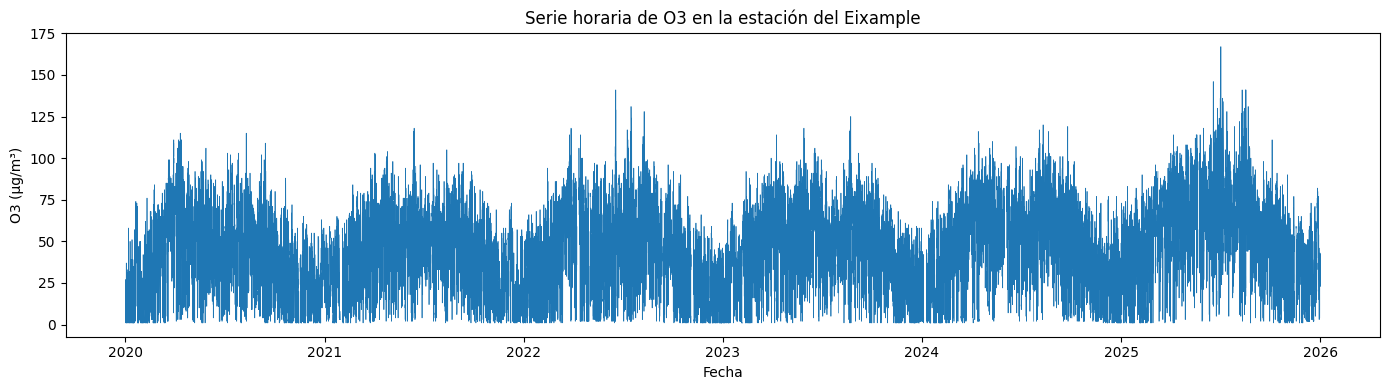

In [8]:
# Esta es la primera visualización global de la serie.
# La figura permite detectar visualmente lapsos sin registros, valores extremos,
# cambios de nivel y patrones estacionales de largo plazo.
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(hourly_df["timestamp"], hourly_df["o3"], linewidth=0.5)

ax.set_title("Serie horaria de O3 en la estación del Eixample")
ax.set_xlabel("Fecha")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

# La figura se guarda en /generated porque todavía cuenta con carácter exploratorio.
# Más adelante se guardarán las figuras finales en reports/figures/final/.
fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_full_series.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [9]:
# En la auditoría previa, se ha inspeccionado todo el periodo 2020-2025; sin embargo,
# para extraer conclusiones que contribuyan a guiar el modelado, se excluirá el año 2025,
# ya que es el año que se reserva como conjunto de prueba.
eda_df = hourly_df[hourly_df["timestamp"].dt.year <= 2024].copy()

# Se añaden variables temporales simples para facilitar los análisis agrupados.
eda_df["year"] = eda_df["timestamp"].dt.year
eda_df["month"] = eda_df["timestamp"].dt.month
eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek

print(f"Inicio EDA para modelado: {eda_df['timestamp'].min()}")
print(f"Fin EDA para modelado: {eda_df['timestamp'].max()}")
print(f"Filas consideradas: {len(eda_df):,}")

Inicio EDA para modelado: 2020-01-01 00:00:00
Fin EDA para modelado: 2024-12-31 23:00:00
Filas consideradas: 43,848


In [10]:
# Se calcula el porcentaje de valores ausentes por año y mes.
# Esto permitirá detectar si los huecos se concentran en periodos concretos
# o si, en caso contrario, están distribuidos de forma relativamente homogénea.
missing_by_month = (
    hourly_df.assign(
        year=hourly_df["timestamp"].dt.year,
        month=hourly_df["timestamp"].dt.month,
    )
    .groupby(["year", "month"])["o3"]
    .apply(lambda values: values.isna().mean() * 100)
    .unstack("month")
)

display(missing_by_month.round(2))

missing_by_month.to_csv(TABLES_DIR / "eda_missing_by_month.csv")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,0.54,0.72,0.81,1.53,0.27,0.69,0.81,0.27,0.42,0.94,8.19,0.94
2021,9.27,3.42,1.08,4.17,10.75,0.56,5.91,0.54,0.42,0.54,0.83,0.94
2022,0.27,0.30,0.81,13.33,10.22,2.08,0.54,0.54,7.08,0.54,16.39,1.34
2023,0.54,1.19,0.81,0.83,1.08,7.22,2.02,0.94,0.14,0.81,1.11,4.30
2024,17.20,0.57,0.40,4.72,2.42,12.22,4.30,0.67,1.25,1.08,1.67,0.81
2025,1.08,1.34,5.51,2.36,8.20,4.44,13.44,1.88,1.25,0.81,10.42,0.94


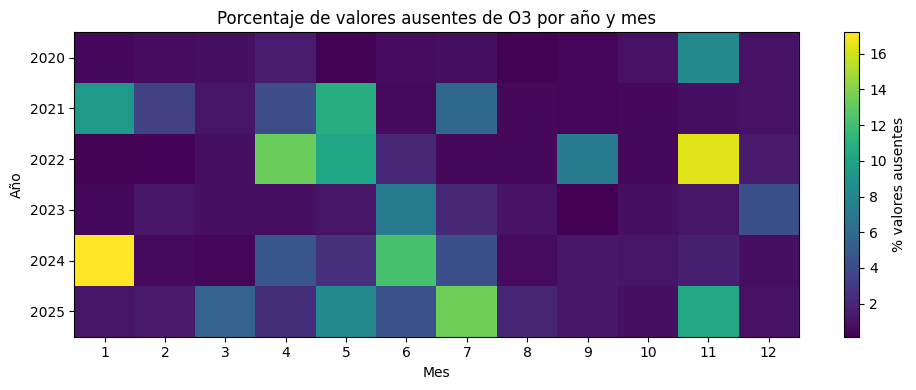

In [11]:
# A continuación, se realiza una visualización de los valores ausentes por año y mes.
# La figura obtenida ayudará a identificar rápidamente si hay meses problemáticos.
fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(missing_by_month.values, aspect="auto")

ax.set_title("Porcentaje de valores ausentes de O3 por año y mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")

ax.set_xticks(np.arange(len(missing_by_month.columns)))
ax.set_xticklabels(missing_by_month.columns)

ax.set_yticks(np.arange(len(missing_by_month.index)))
ax.set_yticklabels(missing_by_month.index)

fig.colorbar(image, ax=ax, label="% valores ausentes")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_missing_by_month.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [12]:
# Se analiza la distribución de la concentración de O3 para 
# detectar asimetrías, valores extremos y también representar las colas.
valid_o3 = eda_df["o3"].dropna()

distribution_summary = valid_o3.describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(distribution_summary.to_frame(name="o3"))

distribution_summary.to_csv(TABLES_DIR / "eda_o3_distribution_summary.csv")

,o3
count,42561.000000
mean,43.897347
std,24.854590
min,1.000000
1%,1.000000
5%,2.000000
25%,25.000000
50%,45.000000
75%,62.000000
95%,83.000000


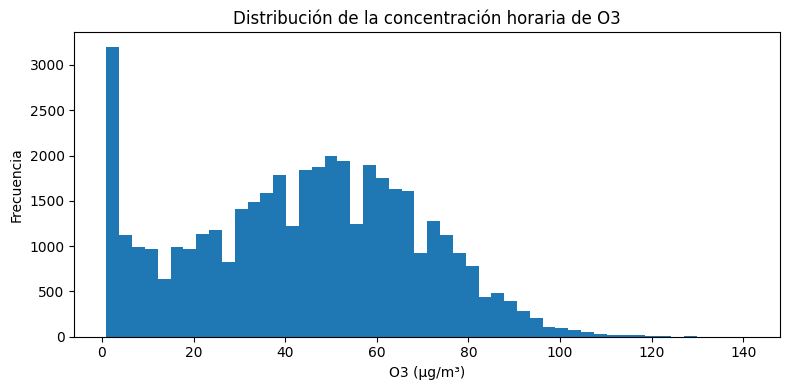

In [13]:
# Se dibuja un histograma de la concentración de O3
# a fin de observar la forma de la distribución y las mencionadas colas.
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(valid_o3, bins=50)

ax.set_title("Distribución de la concentración horaria de O3")
ax.set_xlabel("O3 (µg/m³)")
ax.set_ylabel("Frecuencia")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_histogram.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [14]:
# Se calcula el perfil horario medio y mediano.
# Esto permite comprobar si existe un ciclo diario claro en la concentración de O3.

hourly_profile = (
    eda_df.groupby("hour")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

display(hourly_profile.round(2))

hourly_profile.to_csv(TABLES_DIR / "eda_hourly_profile.csv")

,mean_o3,median_o3,std_o3,count
hour,,,,
0,40.41,43.0,23.96,1788
1,40.51,43.0,23.32,1783
2,39.39,41.0,22.85,1781
3,38.50,41.0,22.80,1787
4,38.17,41.0,22.62,1787
5,36.00,38.0,21.93,1785
6,31.14,32.0,21.03,1785
7,24.76,22.0,19.30,1784
8,24.56,22.0,19.10,1778


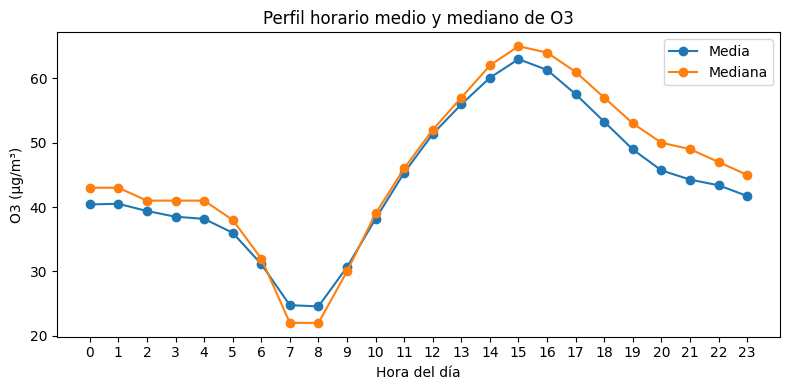

In [15]:
# Se dibuja la gráfica del perfil horario.
# Si aparece un patrón claro por hora del día, esto justificará incluir variables
# de calendario y retardos asociados al ciclo diario.
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hourly_profile.index, hourly_profile["mean_o3"], marker="o", label="Media")
ax.plot(hourly_profile.index, hourly_profile["median_o3"], marker="o", label="Mediana")

ax.set_title("Perfil horario medio y mediano de O3")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 (µg/m³)")
ax.set_xticks(range(0, 24))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_hourly_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [16]:
# Se calcula el perfil mensual de O3.
# Este análisis permite comprobar la existencia de estacionalidad anual.

monthly_profile = (
    eda_df.groupby("month")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

display(monthly_profile.round(2))

monthly_profile.to_csv(TABLES_DIR / "eda_monthly_profile.csv")

,mean_o3,median_o3,std_o3,count
month,,,,
1,25.05,24.0,18.72,3513
2,33.71,36.0,22.29,3366
3,52.60,56.0,23.40,3691
4,59.25,64.0,25.03,3423
5,52.50,55.0,23.05,3536
6,53.49,55.0,21.91,3436
7,51.74,53.0,20.67,3619
8,56.80,57.0,21.79,3698
9,50.56,52.0,21.26,3533


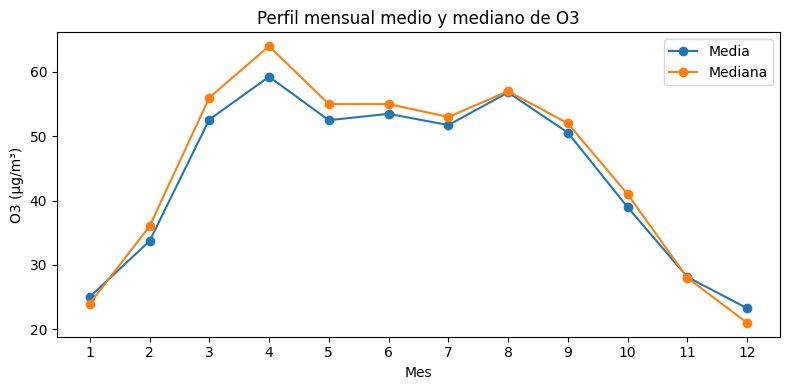

In [17]:
# Visualización del perfil mensual.
# Un patrón mensual claro justificaría incluir variables de calendario anual
# y también ayuda a interpretar la formación fotoquímica del O3.
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(monthly_profile.index, monthly_profile["mean_o3"], marker="o", label="Media")
ax.plot(monthly_profile.index, monthly_profile["median_o3"], marker="o", label="Mediana")

ax.set_title("Perfil mensual medio y mediano de O3")
ax.set_xlabel("Mes")
ax.set_ylabel("O3 (µg/m³)")
ax.set_xticks(range(1, 13))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_monthly_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [18]:
# Se calcula el perfil por día de la semana.
# El objetivo es comprobar si existen diferencias entre días laborables y fin de semana.
weekday_profile = (
    eda_df.groupby("day_of_week")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

weekday_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

weekday_profile = weekday_profile.rename(index=weekday_names)

display(weekday_profile.round(2))

weekday_profile.to_csv(TABLES_DIR / "eda_weekday_profile.csv")

,mean_o3,median_o3,std_o3,count
day_of_week,,,,
Lunes,42.68,44.0,24.34,5993
Martes,41.92,43.0,23.97,6108
Miércoles,42.02,43.0,24.64,6134
Jueves,42.27,44.0,25.10,6101
Viernes,42.23,44.0,25.08,6088
Sábado,47.59,49.0,25.16,6106
Domingo,48.63,50.0,24.66,6031


In [19]:
# A continuación, se observará la correlación del O3 actual con los valores de horas anteriores.
# Para calcular esta correlación correctamente, la serie deberá tener una observación en cada hora;
# como hay algunos valores de O3 ausentes, se rellenarán temporalmente, solo para este análisis.
o3_series = (
    eda_df.set_index("timestamp")["o3"]
    .asfreq("h")
    .interpolate(limit_direction="both")
)

# Se calcula la autocorrelación hasta 7 días atrás
max_lag = 24 * 7
acf_values = acf(o3_series, nlags=max_lag, fft=True)

selected_lags = [1, 2, 3, 4, 6, 12, 24, 48, 72, 168]

acf_summary = pd.DataFrame(
    {
        "lag_hours": selected_lags,
        "autocorrelation": [acf_values[lag] for lag in selected_lags],
    }
)

display(acf_summary.round(4))

acf_summary.to_csv(TABLES_DIR / "eda_selected_lag_autocorrelation.csv", index=False)

,lag_hours,autocorrelation
0,1,0.9252
1,2,0.8207
2,3,0.7166
3,4,0.6169
4,6,0.4477
5,12,0.2626
6,24,0.6340
7,48,0.5502
8,72,0.5212
9,168,0.5246


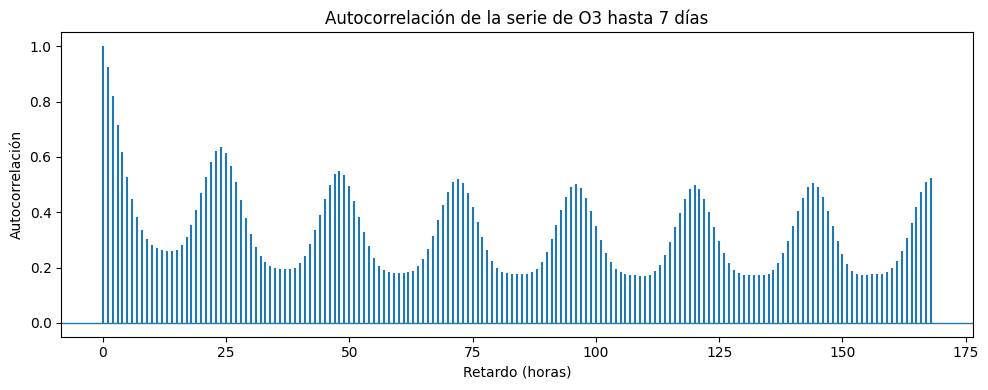

In [20]:
# Visualización de la autocorrelación hasta 7 días en el pasado.
# Los picos en los retardos de 24, 48 o 168 horas ayudan a identificar ciclos diarios o semanales,
# justificar los lags candidatos y fundamentar la regla del modelo base ingenuo estacional.
fig, ax = plt.subplots(figsize=(10, 4))

lags = np.arange(len(acf_values))

ax.vlines(lags, ymin=0, ymax=acf_values)
ax.axhline(0, linewidth=1)

ax.set_title("Autocorrelación de la serie de O3 hasta 7 días")
ax.set_xlabel("Retardo (horas)")
ax.set_ylabel("Autocorrelación")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_acf_7_days.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

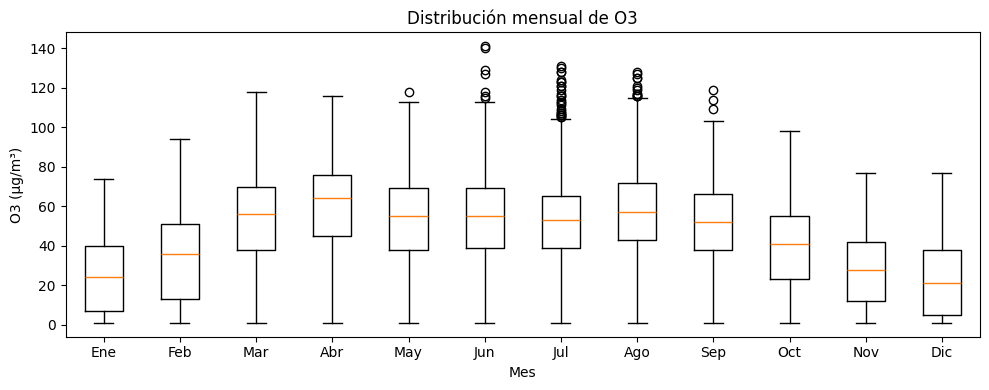

In [21]:
# Se crean boxplots que permiten ver no solo la media mensual, sino también la dispersión
# y la presencia de valores extremos en cada mes.
plot_df = eda_df.dropna(subset=["o3"]).copy()

month_labels = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic",
]

monthly_boxplot_data = [
    plot_df.loc[plot_df["month"] == month, "o3"].to_numpy()
    for month in range(1, 13)
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(monthly_boxplot_data, tick_labels=month_labels, showfliers=True)

ax.set_title("Distribución mensual de O3")
ax.set_xlabel("Mes")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_monthly_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [22]:
# Se calculan estadísticos robustos por mes para complementar el boxplot.
# Los percentiles permiten describir mejor la variabilidad que una media simple.
monthly_distribution_summary = (
    plot_df.groupby("month")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

monthly_distribution_summary.index = month_labels

display(monthly_distribution_summary.round(2))

monthly_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_monthly_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
Ene,3513,25.05,24.0,18.72,7.0,40.0,57.0,74.0
Feb,3366,33.71,36.0,22.29,13.0,51.0,69.0,94.0
Mar,3691,52.60,56.0,23.40,38.0,70.0,86.0,118.0
Abr,3423,59.25,64.0,25.03,45.0,76.0,95.0,116.0
May,3536,52.50,55.0,23.05,38.0,69.0,86.0,118.0
Jun,3436,53.49,55.0,21.91,39.0,69.0,86.0,141.0
Jul,3619,51.74,53.0,20.67,39.0,65.0,85.0,131.0
Ago,3698,56.80,57.0,21.79,43.0,72.0,91.0,128.0
Sep,3533,50.56,52.0,21.26,38.0,66.0,83.0,119.0
Oct,3691,38.97,41.0,21.38,23.0,55.0,71.0,98.0


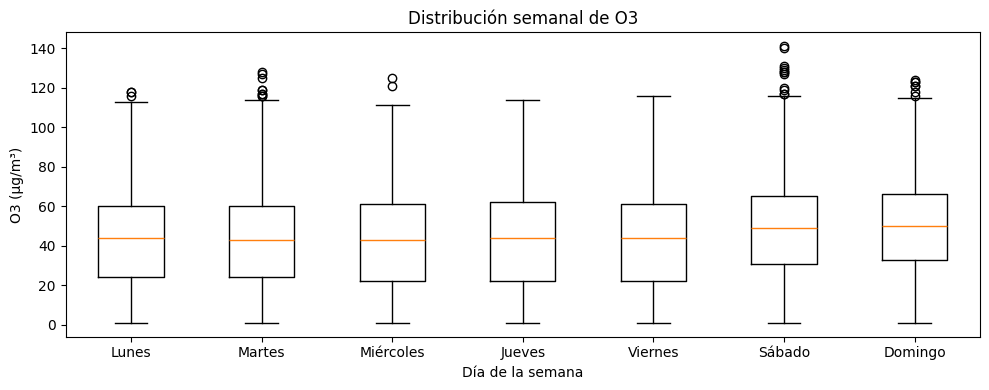

In [23]:
# Se analiza la distribución de O3 según el día de la semana.
# El objetivo es comprobar si los fines de semana presentan un comportamiento distinto
# al de los días laborables.
weekday_labels = [
    "Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo",
]

weekday_boxplot_data = [
    plot_df.loc[plot_df["day_of_week"] == day, "o3"].to_numpy()
    for day in range(7)
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(weekday_boxplot_data, tick_labels=weekday_labels, showfliers=True)

ax.set_title("Distribución semanal de O3")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_weekday_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [24]:
# Se calculan estadísticos por día de la semana para resumir el patrón semanal.
weekday_distribution_summary = (
    plot_df.groupby("day_of_week")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

weekday_distribution_summary.index = weekday_labels

display(weekday_distribution_summary.round(2))

weekday_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_weekday_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
Lunes,5993,42.68,44.0,24.34,24.0,60.0,81.0,118.0
Martes,6108,41.92,43.0,23.97,24.0,60.0,79.0,128.0
Miércoles,6134,42.02,43.0,24.64,22.0,61.0,81.0,125.0
Jueves,6101,42.27,44.0,25.10,22.0,62.0,82.0,114.0
Viernes,6088,42.23,44.0,25.08,22.0,61.0,83.0,116.0
Sábado,6106,47.59,49.0,25.16,31.0,65.0,88.0,141.0
Domingo,6031,48.63,50.0,24.66,33.0,66.0,86.5,124.0


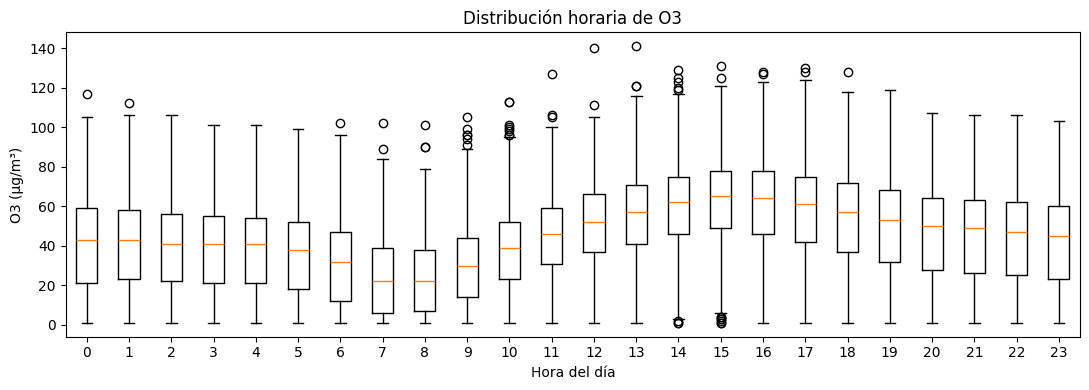

In [25]:
# Se analiza la distribución de O3 por hora del día.
# Este gráfico permite comprobar la estacionalidad diaria no solo mediante la media,
# sino también observando la mediana, la dispersión y los valores atípicos de cada hora.
hourly_boxplot_data = [
    plot_df.loc[plot_df["hour"] == hour, "o3"].to_numpy()
    for hour in range(24)
]

fig, ax = plt.subplots(figsize=(11, 4))

ax.boxplot(
    hourly_boxplot_data,
    tick_labels=range(24),
    showfliers=True,
)

ax.set_title("Distribución horaria de O3")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_hourly_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [26]:
# Se calculan estadísticos por hora para complementar el boxplot horario.
# Esta tabla será útil para redactar la memoria y justificar variables temporales
# como la hora del día y los retardos diarios.
hourly_distribution_summary = (
    plot_df.groupby("hour")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

display(hourly_distribution_summary.round(2))

hourly_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_hourly_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
hour,,,,,,,,
0,1788,40.41,43.0,23.96,21.0,59.0,77.00,117.0
1,1783,40.51,43.0,23.32,23.0,58.0,75.00,112.0
2,1781,39.39,41.0,22.85,22.0,56.0,75.00,106.0
3,1787,38.50,41.0,22.80,21.0,55.0,75.00,101.0
4,1787,38.17,41.0,22.62,21.0,54.0,74.00,101.0
5,1785,36.00,38.0,21.93,18.0,52.0,70.00,99.0
6,1785,31.14,32.0,21.03,12.0,47.0,66.00,102.0
7,1784,24.76,22.0,19.30,6.0,39.0,58.00,102.0
8,1778,24.56,22.0,19.10,7.0,38.0,59.15,101.0


In [27]:
# Se calcula la concentración media de O3 para cada combinación de mes y hora.
# El resultado permite estudiar si el ciclo diario cambia según la época del año.
month_hour_matrix = (
    plot_df.groupby(["month", "hour"])["o3"]
    .mean()
    .unstack("hour")
    .reindex(index=range(1, 13), columns=range(24))
)

display(month_hour_matrix.round(2))

month_hour_matrix.to_csv(TABLES_DIR / "eda_o3_month_hour_matrix.csv")

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,,,,
1,22.01,24.51,25.47,26.75,27.41,26.86,22.72,16.80,14.06,16.80,21.59,28.08,33.12,34.22,37.52,38.94,35.49,29.59,23.19,18.88,17.77,19.14,20.04,21.12
2,26.97,28.50,29.25,29.87,29.75,27.77,24.09,17.82,15.65,20.11,29.53,37.81,41.47,46.90,52.30,54.73,52.87,48.27,41.62,36.79,32.57,29.39,28.70,27.44
3,49.24,48.58,47.82,47.75,48.39,46.04,39.14,30.88,30.86,37.86,46.47,53.53,60.19,65.23,70.05,71.89,70.66,67.59,62.79,56.89,55.09,53.43,53.00,50.17
4,56.95,55.94,52.60,51.85,49.31,45.67,40.06,31.43,31.08,39.89,48.63,55.75,64.89,71.50,76.38,80.72,81.05,78.78,76.43,72.44,68.64,66.58,63.69,60.83
5,49.57,46.85,42.93,40.90,38.79,37.01,32.04,26.17,29.86,38.73,44.76,53.09,58.72,65.25,70.38,74.55,73.99,71.63,69.35,65.35,60.28,58.85,57.42,54.07
6,51.39,49.64,46.66,43.37,42.81,37.65,33.14,29.77,32.81,38.80,47.50,55.91,62.55,67.50,70.04,73.19,71.90,69.79,67.05,63.58,60.64,58.90,55.61,53.48
7,49.21,48.01,45.35,42.03,40.40,37.17,31.79,27.82,31.15,38.75,46.69,54.93,61.11,66.38,68.66,70.96,69.95,68.45,65.68,60.89,56.54,55.08,53.84,51.65
8,51.86,50.59,49.03,47.06,46.59,43.81,38.72,32.41,35.22,43.64,50.45,57.87,66.50,72.12,76.09,78.31,76.98,74.08,70.34,66.32,62.34,60.10,58.15,54.90
9,48.52,48.23,46.29,44.37,43.03,40.95,36.13,27.55,24.39,33.18,41.61,48.70,55.27,61.54,67.32,72.02,71.87,68.91,64.39,59.34,54.87,53.27,52.06,49.89


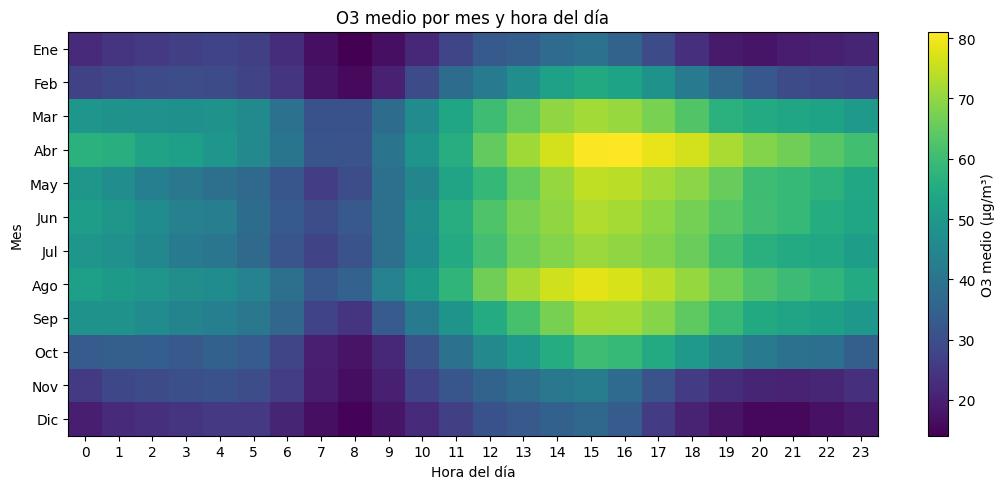

In [28]:
# Se dibuja un mapa de calor del O3 medio por mes y hora.
# Las filas representan meses y las columnas horas del día.
# Los patrones de color permiten identificar cuándo se concentran los valores más altos.
fig, ax = plt.subplots(figsize=(11, 5))

image = ax.imshow(month_hour_matrix.values, aspect="auto")

ax.set_title("O3 medio por mes y hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mes")

ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24))

ax.set_yticks(np.arange(12))
ax.set_yticklabels(month_labels)

fig.colorbar(image, ax=ax, label="O3 medio (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_month_hour_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [29]:
# Esta tabla resume cómo los hallazgos de la EDA se traducen en decisiones de modelado.
# Es útil para conectar el análisis exploratorio con la fase posterior de entrenamiento.
eda_modeling_implications = pd.DataFrame(
    [
        {
            "eda_finding": "Ciclo horario marcado",
            "modeling_implication": "Incluir variables de hora y retardos de corto plazo.",
        },
        {
            "eda_finding": "Estacionalidad mensual",
            "modeling_implication": "Incluir variables de mes o codificación cíclica anual.",
        },
        {
            "eda_finding": "Diferencias entre laborables y fines de semana",
            "modeling_implication": "Incluir día de la semana como variable predictiva.",
        },
        {
            "eda_finding": "Autocorrelación alta en retardos cortos",
            "modeling_implication": "Considerar lags como 1, 2, 3, 6 y 12 horas.",
        },
        {
            "eda_finding": "Autocorrelación relevante en 24 y 168 horas",
            "modeling_implication": "Justificar el modelo base ingenuo estacional y considerar lags diarios/semanales.",
        },
        {
            "eda_finding": "Valores ausentes concentrados en ciertos meses",
            "modeling_implication": "Definir una estrategia de tratamiento de ausentes antes del entrenamiento.",
        },
    ]
)

display(eda_modeling_implications)

eda_modeling_implications.to_csv(
    TABLES_DIR / "eda_modeling_implications.csv",
    index=False,
)

,eda_finding,modeling_implication
0,Ciclo horario marcado,Incluir variables de hora y retardos de corto ...
1,Estacionalidad mensual,Incluir variables de mes o codificación cíclic...
2,Diferencias entre laborables y fines de semana,Incluir día de la semana como variable predict...
3,Autocorrelación alta en retardos cortos,"Considerar lags como 1, 2, 3, 6 y 12 horas."
4,Autocorrelación relevante en 24 y 168 horas,Justificar el modelo base ingenuo estacional y...
5,Valores ausentes concentrados en ciertos meses,Definir una estrategia de tratamiento de ausen...
